In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


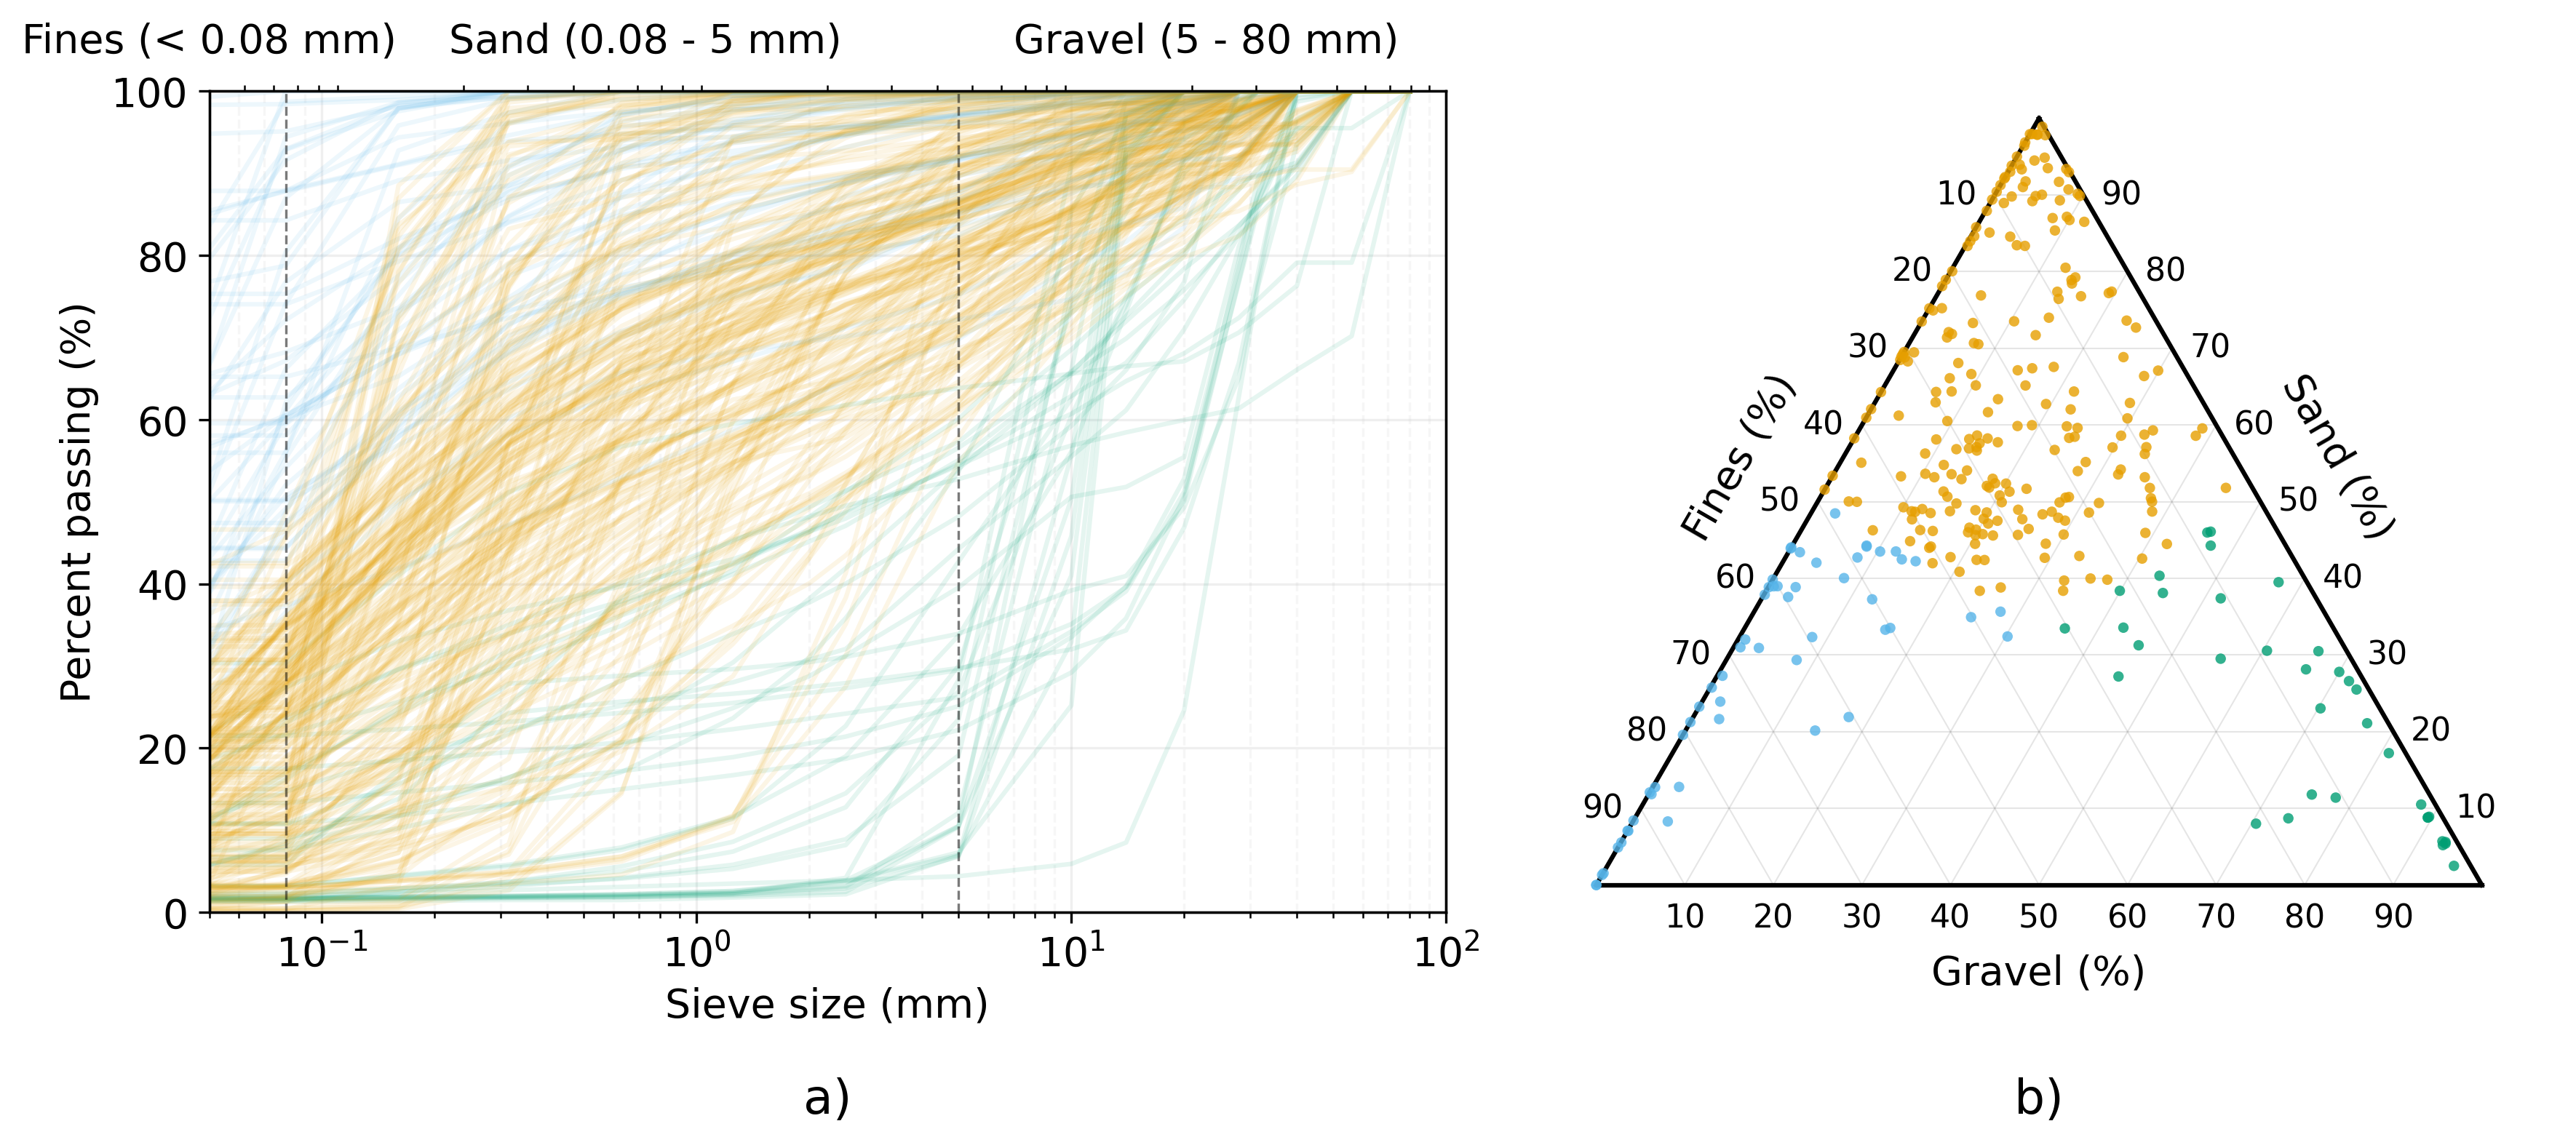

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# General variable to adjust the scale of all text
text_scale = 1.33
plt.rcParams.update({'font.size': 10 * text_scale})

path_psd = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD.xlsx"

try:
    df = pd.read_excel(path_psd)
except FileNotFoundError:
    df = pd.read_csv("PSD.xlsx - Sheet1.csv")
    
psd_cols = [
    "%_80mm", "%_56mm", "%_40mm", "%_31.5mm", "%_28mm", "%_20mm",
    "%_14mm", "%_10mm", "%_5mm", "%_2.5mm", "%_2mm", "%_1.25mm",
    "%_0.63mm", "%_0.315mm", "%_0.16mm", "%_0.08mm", "%_0.05mm",
]

df_psd = df[psd_cols].copy()
mask_valid = df_psd.notna().all(axis=1)
df_psd = df_psd.loc[mask_valid].reset_index(drop=True)
X = df_psd.to_numpy(dtype=float)

sieve_d = np.array([float(c.split("_")[1].replace("mm", "")) for c in psd_cols])
sort_idx = np.argsort(sieve_d)
sieve_d_sorted = sieve_d[sort_idx]

cols_needed = ["%_80mm", "%_5mm", "%_0.08mm"]
df_valid = df.dropna(subset=cols_needed).copy()

gravel = df_valid["%_80mm"] - df_valid["%_5mm"]
sand = df_valid["%_5mm"] - df_valid["%_0.08mm"]
fines = df_valid["%_0.08mm"]

total = gravel + sand + fines
gravel_frac = gravel / total
sand_frac = sand / total
fines_frac = fines / total

x_tern = gravel_frac + 0.5 * sand_frac
y_tern = (np.sqrt(3) / 2) * sand_frac
H = np.sqrt(3) / 2

c_fines = "#56B4E9"
c_sand = "#E69F00"
c_gravel = "#009E73"

fig = plt.figure(figsize=(12, 5), dpi=300)
gs = GridSpec(1, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[0])
xmin = 0.05

fines_2mm = df_psd["%_2mm"].to_numpy(dtype=float)
order = np.argsort(fines_2mm)

for idx in order:
    g = gravel_frac.iloc[idx]
    s = sand_frac.iloc[idx]
    f = fines_frac.iloc[idx]
    if g >= s and g >= f:
        c = c_gravel
    elif s >= g and s >= f:
        c = c_sand
    else:
        c = c_fines
    ax1.plot(sieve_d_sorted, X[idx, sort_idx], color=c, alpha=0.1)

ax1.set_xscale("log")
ax1.set_xlim(xmin, 100)
ax1.set_ylim(0, 100)
ax1.set_xlabel("Sieve size (mm)", fontsize=10 * text_scale)
ax1.set_ylabel("Percent passing (%)", fontsize=10 * text_scale)
ax1.grid(True, which="major", ls="-", alpha=0.2)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

ax1_top = ax1.twiny()
ax1_top.set_xscale("log")
ax1_top.set_xlim(ax1.get_xlim())
ax1_top.set_xticks([0.04, 0.63, 22])
ax1_top.set_xticklabels(["Fines (< 0.08 mm)", "Sand (0.08 - 5 mm)", "Gravel (5 - 80 mm)"], fontsize=10 * text_scale)
ax1_top.tick_params(axis='x', length=0, pad=10)

ax1.axvline(0.08, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(5, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

ax2 = fig.add_subplot(gs[1])

for i in range(1, 10):
    frac = i / 10.0
    ax2.plot([0.5 * frac, 1 - 0.5 * frac], [H * frac, H * frac], color='gray', linestyle='-', linewidth=0.5, alpha=0.2, zorder=1)
    ax2.plot([frac, 0.5 + 0.5 * frac], [0, H * (1 - frac)], color='gray', linestyle='-', linewidth=0.5, alpha=0.2, zorder=1)
    ax2.plot([1 - frac, 0.5 - 0.5 * frac], [0, H * (1 - frac)], color='gray', linestyle='-', linewidth=0.5, alpha=0.2, zorder=1)
    
    ax2.text(1 - 0.5 * frac + 0.02, H * frac, f"{int(frac*100)}", color='black', fontsize=8 * text_scale, ha='left', va='center')
    ax2.text(frac, -0.02, f"{int(frac*100)}", color='black', fontsize=8 * text_scale, ha='center', va='top')
    ax2.text(0.5 - 0.5 * frac - 0.02, H * (1 - frac), f"{int(frac*100)}", color='black', fontsize=8 * text_scale, ha='right', va='center')

ax2.plot([0, 1], [0, 0], color='black', lw=1.5, zorder=2)
ax2.plot([1, 0.5], [0, H], color='black', lw=1.5, zorder=2)
ax2.plot([0.5, 0], [H, 0], color='black', lw=1.5, zorder=2)

colors_scatter = []
for i in range(len(gravel_frac)):
    g = gravel_frac.iloc[i]
    s = sand_frac.iloc[i]
    f = fines_frac.iloc[i]
    if g >= s and g >= f:
        colors_scatter.append(c_gravel)
    elif s >= g and s >= f:
        colors_scatter.append(c_sand)
    else:
        colors_scatter.append(c_fines)

ax2.scatter(x_tern, y_tern, c=colors_scatter, alpha=0.8, edgecolors='none', s=12, zorder=3)

# Configurable variables for text distances and overall plot padding
label_dist_fines = 0.10
label_dist_sand = 0.10
label_dist_gravel = 0.1
triangle_padding = 0.15

# Calculate exact geometric offsets based on a 30 degree trigonometric normal
ax2.text(0.5, -label_dist_gravel, 'Gravel (%)', color='black', ha='center', va='center', fontsize=10 * text_scale)
ax2.text(0.75 + label_dist_sand * np.cos(np.radians(30)), H/2 + label_dist_sand * np.sin(np.radians(30)), 'Sand (%)', color='black', ha='center', va='center', fontsize=10 * text_scale, rotation=-60)
ax2.text(0.25 - label_dist_fines * np.cos(np.radians(30)), H/2 + label_dist_fines * np.sin(np.radians(30)), 'Fines (%)', color='black', ha='center', va='center', fontsize=10 * text_scale, rotation=60)

ax2.axis('equal')
ax2.axis('off')

# Explicit boundary control forces matplotlib to keep the defined padding distances
ax2.set_xlim(0 - triangle_padding, 1 + triangle_padding)
ax2.set_ylim(0 - triangle_padding, H + triangle_padding)

plt.tight_layout()
ax1.text(0.5, -0.2, 'a)', transform=ax1.transAxes, ha='center', va='top', fontsize=12 * text_scale)
ax2.text(0.5, -0.2, 'b)', transform=ax2.transAxes, ha='center', va='top', fontsize=12 * text_scale,)
plt.show()

In [12]:
import pandas as pd
from IPython.display import display

file_path = '/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD_paths_geomanitoba.xlsx'
excel_data = pd.read_excel(file_path, sheet_name=None)

dfs = []
for sheet_name in excel_data:
    df = excel_data[sheet_name]
    df = df.rename(columns={'dry or moist': 'dry_or_moist'})
    if 'trays' in df.columns and 'dry_or_moist' in df.columns and '%_80mm' in df.columns:
        dfs.append(df[['trays', 'dry_or_moist', '%_80mm']])

df_combined = pd.concat(dfs, ignore_index=True)
df_combined = df_combined.dropna(subset=['%_80mm'])
df_combined['trays'] = pd.to_numeric(df_combined['trays'], errors='coerce')
df_combined = df_combined.dropna(subset=['trays', 'dry_or_moist'])
df_combined['dry_or_moist'] = df_combined['dry_or_moist'].astype(str).str.lower().str.strip()

categories = [
    'Sample with 1 tray', 
    'Sample with 2 tray', 
    'Sample with 3 tray', 
    'Sample with 4 tray', 
    'Sample with >4 tray'
]

results = {cat: {'Total': 0, 'Moist': 0, 'Dry': 0} for cat in categories}
results['Total sample with sieving'] = {'Total': 0, 'Moist': 0, 'Dry': 0}

for _, row in df_combined.iterrows():
    t = row['trays']
    dom = row['dry_or_moist']
    
    if pd.isna(t) or t < 1:
        continue
        
    if t == 1:
        c = 'Sample with 1 tray'
    elif t == 2:
        c = 'Sample with 2 tray'
    elif t == 3:
        c = 'Sample with 3 tray'
    elif t == 4:
        c = 'Sample with 4 tray'
    else:
        c = 'Sample with >4 tray'

    results[c]['Total'] += 1
    results['Total sample with sieving']['Total'] += 1
    
    if dom in ['moist', 'both']:
        results[c]['Moist'] += 1
        results['Total sample with sieving']['Moist'] += 1
    if dom in ['dry', 'both']:
        results[c]['Dry'] += 1
        results['Total sample with sieving']['Dry'] += 1

data = [[
    'Total sample with sieving', 
    results['Total sample with sieving']['Total'], 
    results['Total sample with sieving']['Moist'], 
    results['Total sample with sieving']['Dry']
]]

for cat in categories:
    data.append([cat, results[cat]['Total'], results[cat]['Moist'], results[cat]['Dry']])

df_summary = pd.DataFrame(data, columns=['Characteristic', 'Total', 'Moist', 'Dry'])
display(df_summary)

,Characteristic,Total,Moist,Dry
0,Total sample with sieving,316,302,296
1,Sample with 1 tray,145,136,140
2,Sample with 2 tray,2,2,2
3,Sample with 3 tray,2,2,2
4,Sample with 4 tray,162,162,147
5,Sample with >4 tray,5,0,5


In [13]:
import os
import re
import pandas as pd
from IPython.display import display

# Path to the Excel file containing lab data
excel_path = '/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD_paths_geomanitoba.xlsx'
excel_data = pd.read_excel(excel_path, sheet_name=None)

valid_samples = set()

# Filter samples that have sieving analysis (non-empty %_80mm)
for sheet_name in excel_data:
    df = excel_data[sheet_name]
    df.columns = df.columns.astype(str).str.strip()
    
    if 'num_publication' in df.columns and '%_80mm' in df.columns:
        valid_df = df.dropna(subset=['%_80mm'])
        for val in valid_df['num_publication'].dropna():
            try:
                valid_samples.add(int(val))
            except ValueError:
                pass

# Path to the directory containing images
directory_path = '/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/rig_v1_images/images_soil_geomanitoba'

sample_tray_counts = {}
pattern = re.compile(r'^(\d+)_.*?(dry|moist)_tray(\d+)_\d+\.jpg$')

if os.path.exists(directory_path):
    for filename in os.listdir(directory_path):
        match = pattern.match(filename)
        if match:
            sample_num_str = match.group(1)
            moisture = match.group(2)
            tray_num = match.group(3)
            
            try:
                sample_num = int(sample_num_str)
            except ValueError:
                continue
            
            # Skip samples without sieving data
            if sample_num not in valid_samples:
                continue
            
            # Unique identifier for each tray within a sample (moisture + tray number)
            tray_id = f"{moisture}_{tray_num}"
            
            if sample_num not in sample_tray_counts:
                sample_tray_counts[sample_num] = {}
                
            if tray_id not in sample_tray_counts[sample_num]:
                sample_tray_counts[sample_num][tray_id] = 0
                
            sample_tray_counts[sample_num][tray_id] += 1

# Dictionaries to store frequency distributions
dist_total = {}
dist_1t = {}
dist_2t = {}
dist_3t = {}
dist_4t = {}
dist_gt4t = {}

for sample_num, trays in sample_tray_counts.items():
    min_imgs = min(trays.values())
    
    # Identify unique physical trays by number to determine the tray count category
    physical_tray_ids = {tid.split('_')[1] for tid in trays.keys()}
    num_trays = len(physical_tray_ids)
    
    dist_total[min_imgs] = dist_total.get(min_imgs, 0) + 1
    
    if num_trays == 1:
        dist_1t[min_imgs] = dist_1t.get(min_imgs, 0) + 1
    elif num_trays == 2:
        dist_2t[min_imgs] = dist_2t.get(min_imgs, 0) + 1
    elif num_trays == 3:
        dist_3t[min_imgs] = dist_3t.get(min_imgs, 0) + 1
    elif num_trays == 4:
        dist_4t[min_imgs] = dist_4t.get(min_imgs, 0) + 1
    elif num_trays > 4:
        dist_gt4t[min_imgs] = dist_gt4t.get(min_imgs, 0) + 1

# Define range for the table rows based on found values
max_val = max(dist_total.keys()) if dist_total else 15
max_range = max(max_val, 15)

table_data = []
for i in range(1, max_range + 1):
    table_data.append([
        f"{i} img / tray",
        dist_total.get(i, 0),
        dist_1t.get(i, 0),
        dist_2t.get(i, 0),
        dist_3t.get(i, 0),
        dist_4t.get(i, 0),
        dist_gt4t.get(i, 0)
    ])

df_summary = pd.DataFrame(table_data, columns=[
    'Minimum number of images per tray for a sample', 
    'Total', '1 tray', '2 trays', '3 trays', '4 trays', '>4 trays'
])

display(df_summary)

,Minimum number of images per tray for a sample,Total,1 tray,2 trays,3 trays,4 trays,>4 trays
0,1 img / tray,0,0,0,0,0,0
1,2 img / tray,1,0,0,0,0,1
2,3 img / tray,4,0,0,0,0,4
3,4 img / tray,8,3,0,0,5,0
4,5 img / tray,96,34,1,0,61,0
5,6 img / tray,71,70,1,0,0,0
6,7 img / tray,20,20,0,0,0,0
7,8 img / tray,11,10,0,0,1,0
8,9 img / tray,3,1,0,0,2,0
9,10 img / tray,95,0,0,2,91,2


In [15]:
import os

npz_dir = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/dinov2_features_7616x5440/dinov2_224_grid_34x24"
img_dir = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/rig_v1_images/images_soil_geomanitoba"

npz_suffix = "_dinov2_224_grid_34x24.npz"
img_suffix = ".jpg"

total_npz_size = 0
total_img_size = 0
count = 0

for filename in os.listdir(npz_dir):
    if filename.endswith(npz_suffix):
        base_name = filename.replace(npz_suffix, "")
        img_filename = base_name + img_suffix
        
        npz_path = os.path.join(npz_dir, filename)
        img_path = os.path.join(img_dir, img_filename)
        
        if os.path.exists(img_path):
            total_npz_size += os.path.getsize(npz_path)
            total_img_size += os.path.getsize(img_path)
            count += 1

if count > 0:
    avg_npz_mb = (total_npz_size / count) / (1024 * 1024)
    avg_img_mb = (total_img_size / count) / (1024 * 1024)
    
    total_npz_gb = total_npz_size / (1024 * 1024 * 1024)
    total_img_gb = total_img_size / (1024 * 1024 * 1024)
    
    reduction_percentage = ((total_img_size - total_npz_size) / total_img_size) * 100
    
    print(f"Processed {count} file pairs.")
    print(f"Total JPEG Size Before {total_img_gb:.2f} GB")
    print(f"Total NPZ Size After {total_npz_gb:.2f} GB")
    print(f"Average JPEG Size {avg_img_mb:.2f} MB")
    print(f"Average NPZ Size {avg_npz_mb:.2f} MB")
    print(f"Average Size Reduction {reduction_percentage:.2f}%")
else:
    print("No matching file pairs found.")

Processed 12714 file pairs.
Total JPEG Size Before 404.38 GB
Total NPZ Size After 27.48 GB
Average JPEG Size 32.57 MB
Average NPZ Size 2.21 MB
Average Size Reduction 93.20%


In [ ]:
import os, re
from collections import defaultdict
import pandas as pd

ROOT = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/rig_v1_images/images_soil_geomanitoba"
pat = re.compile(r"^(?P<sample>\d+)_.*?_(?P<moisture>dry|moist)_tray(?P<tray>\d+)_\d+\.(jpg|jpeg|png)$", re.I)

counts = defaultdict(lambda: {"dry": 0, "moist": 0, "total": 0})
tray_counts = defaultdict(lambda: {"dry": defaultdict(int), "moist": defaultdict(int)})

for dirpath, _, files in os.walk(ROOT):
    for fn in files:
        m = pat.match(fn)
        if not m:
            continue
        s = m.group("sample")
        mo = m.group("moisture").lower()
        tr = m.group("tray")
        counts[s][mo] += 1
        counts[s]["total"] += 1
        tray_counts[s][mo][tr] += 1

cols = [
    "No dry Images",
    "No Moist Image",
    "<10 images total (moist+dry)",
    "4 dry image per tray",
    "4 moist images per tray",
    ">4 trays, no moist, min(dry images per tray) < 4",
]
buckets = {c: [] for c in cols}

for s in sorted(counts):
    dry, moist, total = counts[s]["dry"], counts[s]["moist"], counts[s]["total"]
    dry_trays = tray_counts[s]["dry"]
    moist_trays = tray_counts[s]["moist"]

    if dry == 0:
        buckets["No dry Images"].append(s)
    if moist == 0:
        buckets["No Moist Image"].append(s)
    if total < 10:
        buckets["<10 images total (moist+dry)"].append(s)

    # least photographed tray logic (per moisture)
    if dry > 0 and min(dry_trays.values()) == 4:
        buckets["4 dry image per tray"].append(s)

    if moist > 0 and min(moist_trays.values()) == 4:
        buckets["4 moist images per tray"].append(s)

    # LAST COLUMN: flag if there exists an under-photographed tray (<4) among >4 trays, with no moist images
    if moist == 0 and len(dry_trays) > 4:
        if min(dry_trays.values()) < 4:
            buckets[">4 trays, no moist, min(dry images per tray) < 4"].append(s)

max_len = max(len(v) for v in buckets.values()) if buckets else 0
df = pd.DataFrame({c: buckets[c] + [""] * (max_len - len(buckets[c])) for c in cols})
df

,No dry Images,No Moist Image,<10 images total (moist+dry),4 dry image per tray,4 moist images per tray,">4 trays, no moist images, <4 images per tray"
0,0042,0165,0165,0134,0177,0317
1,0057,0185,0265,0135,0178,0318
2,0058,0186,0312,0136,0179,0319
3,0059,0187,0313,0137,,0320
4,0091,0188,0314,0139,,0321
5,0092,0189,0315,,,
6,0093,0190,0316,,,
7,0094,0191,,,,
8,0095,0265,,,,
9,0096,0317,,,,


In [1]:
import os, re
from collections import defaultdict
import pandas as pd

ROOT = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/rig_v1_images/images_soil_geomanitoba"
pat = re.compile(r"^(?P<sample>\d+)_.*?_(?P<moisture>dry|moist)_tray(?P<tray>\d+)_\d+\.(jpg|jpeg|png)$", re.I)

counts = defaultdict(lambda: {"dry": 0, "moist": 0, "total": 0})
tray_counts = defaultdict(lambda: {"dry": defaultdict(int), "moist": defaultdict(int)})

for dirpath, _, files in os.walk(ROOT):
    for fn in files:
        m = pat.match(fn)
        if not m:
            continue
        s = m.group("sample")
        mo = m.group("moisture").lower()
        tr = m.group("tray")
        counts[s][mo] += 1
        counts[s]["total"] += 1
        tray_counts[s][mo][tr] += 1

cols = [
    "No dry Images",
    "No Moist Image",
    "<10 images total (moist+dry)",
    "4 dry image per tray",
    "4 moist images per tray",
    ">4 trays, no moist images, <4 images per tray",
]
buckets = {c: [] for c in cols}

for s in sorted(counts):
    dry, moist, total = counts[s]["dry"], counts[s]["moist"], counts[s]["total"]
    dry_trays = tray_counts[s]["dry"]
    moist_trays = tray_counts[s]["moist"]
    all_trays = set(dry_trays) | set(moist_trays)

    if dry == 0:
        buckets["No dry Images"].append(s)
    if moist == 0:
        buckets["No Moist Image"].append(s)
    if total < 10:
        buckets["<10 images total (moist+dry)"].append(s)

    # least-photographed tray logic
    if dry > 0:
        if min(dry_trays.values()) == 4:
            buckets["4 dry image per tray"].append(s)

    if moist > 0:
        if min(moist_trays.values()) == 4:
            buckets["4 moist images per tray"].append(s)

    if moist == 0 and len(all_trays) > 4:
        per_tray_total = [(dry_trays.get(t, 0) + moist_trays.get(t, 0)) for t in all_trays]
        if min(per_tray_total) < 4:
            buckets[">4 trays, no moist images, <4 images per tray"].append(s)

max_len = max(len(v) for v in buckets.values()) if buckets else 0
df = pd.DataFrame({c: buckets[c] + [""] * (max_len - len(buckets[c])) for c in cols})
df

,No dry Images,No Moist Image,<10 images total (moist+dry),4 dry image per tray,4 moist images per tray,">4 trays, no moist images, <4 images per tray"
0,0042,0165,0165,0134,0177,0317
1,0057,0185,0265,0135,0178,0318
2,0058,0186,0312,0136,0179,0319
3,0059,0187,0313,0137,,0320
4,0091,0188,0314,0139,,0321
5,0092,0189,0315,,,
6,0093,0190,0316,,,
7,0094,0191,,,,
8,0095,0265,,,,
9,0096,0317,,,,


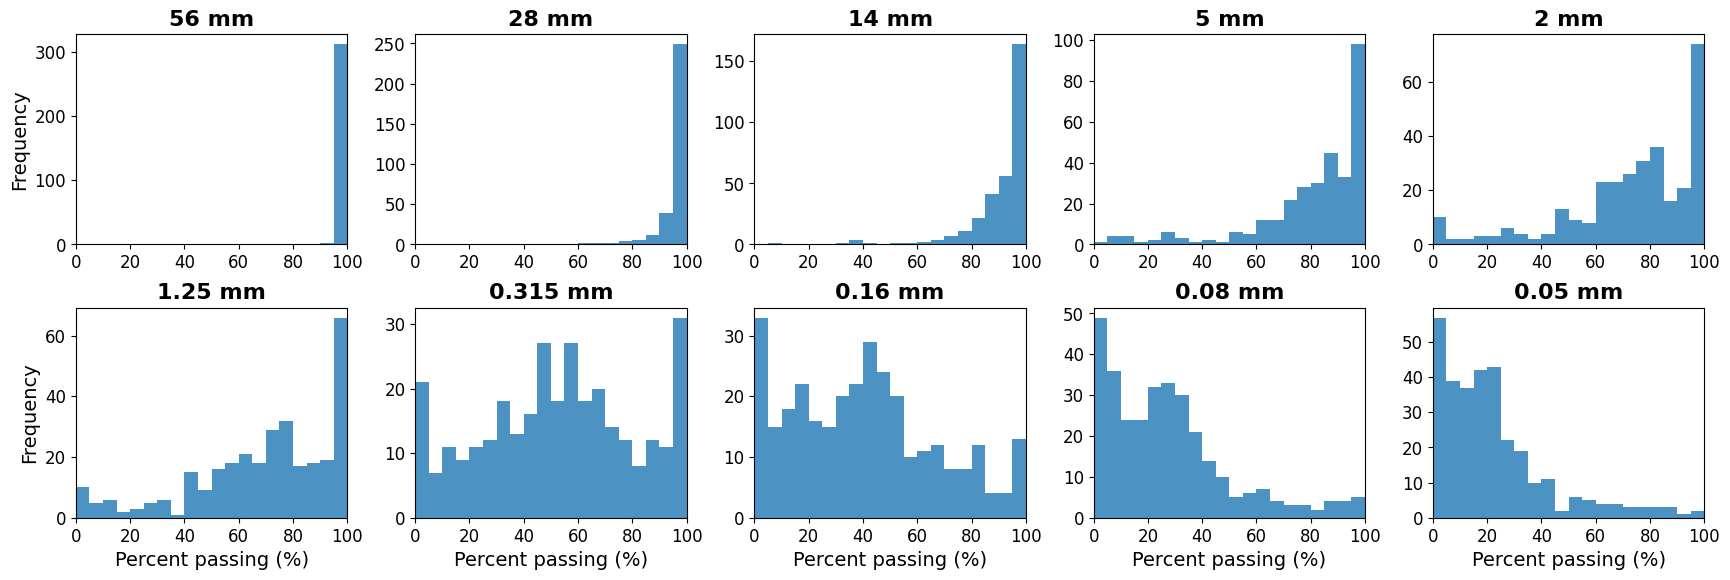

In [16]:
# ---------------------------
# Representative histograms for publication figure (10 bins)
# ---------------------------
selected_psd_cols = [
    "%_56mm", "%_28mm", "%_14mm", "%_5mm", "%_2mm", 
    "%_1.25mm", "%_0.315mm", "%_0.16mm", "%_0.08mm", "%_0.05mm"
]

n_cols = 5
n_plots = len(selected_psd_cols)
n_rows = math.ceil(n_plots / n_cols)

# Adjusted figsize for a 2x5 grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes_flat = axes.ravel()

# fixed 5-wide bins
fixed_bins = np.arange(0, 105, 5)   # 0,5,10,...,100

for i, col in enumerate(selected_psd_cols):
    ax = axes_flat[i]
    data = df_psd[col].dropna().to_numpy()

    # Format the title
    clean_title = col.replace('%_', '').replace('mm', ' mm')
    ax.set_title(clean_title, fontsize=16, fontweight="bold")
    
    # Calculate row and column indices
    row = i // n_cols
    column = i % n_cols
    
    # Only add the X label to the bottom row
    if row == n_rows - 1:
        ax.set_xlabel("Percent passing (%)", fontsize=14)
        
    # Only add the Y label to the leftmost column
    if column == 0:
        ax.set_ylabel("Frequency", fontsize=14)
    
    ax.set_xlim(0, 100)
    ax.tick_params(axis="both", labelsize=12)

    vmin = data.min()
    vmax = data.max()

    if vmin == vmax:
        ax.bar([vmin], [len(data)], width=10, alpha=0.8, align="center")
    else:
        ax.hist(data, bins=fixed_bins, alpha=0.8)

# hide unused axes just in case
for j in range(n_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()

# Control the horizontal and vertical space between subplots
# wspace=0.25 ensures the y-axis tick numbers don't overlap the plot to their left
plt.subplots_adjust(wspace=0.25, hspace=0.3) 

# plt.savefig("fig2_histogram_distribution_10bins.png", dpi=300, bbox_inches='tight')
plt.show()

### PCA visualisation

In [6]:
plt.rcParams["figure.figsize"] = (6, 4)

path_psd = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD.xlsx"

psd_cols = [
    "%_80mm", "%_56mm", "%_40mm", "%_31.5mm", "%_28mm", "%_20mm",
    "%_14mm", "%_10mm", "%_5mm", "%_2.5mm", "%_2mm", "%_1.25mm",
    "%_0.63mm", "%_0.315mm", "%_0.16mm", "%_0.08mm", "%_0.05mm",
]

df = pd.read_excel(path_psd)

sample_ids = df.iloc[:, 0]  # colonne A
df_psd = df[psd_cols].copy()

# Nettoyage NaN, une seule fois au début
mask_valid = df_psd.notna().all(axis=1)
print("Lignes gardées:", mask_valid.sum(), "sur", len(mask_valid))

df_psd = df_psd.loc[mask_valid].reset_index(drop=True)
sample_ids = sample_ids.loc[mask_valid].reset_index(drop=True)

# Matrice numérique sans NaN
X = df_psd.to_numpy(dtype=float)

print("Nb d’échantillons:", X.shape[0])
print("Nb de points PSD par courbe:", X.shape[1])

print(df_psd.describe().T.to_string(line_width=None))

Lignes gardées: 316 sur 321
Nb d’échantillons: 316
Nb de points PSD par courbe: 17
           count        mean        std         min         25%         50%         75%         max
%_80mm     316.0  100.000000   0.000000  100.000000  100.000000  100.000000  100.000000  100.000000
%_56mm     316.0   99.763766   2.195112   70.160000  100.000000  100.000000  100.000000  100.000000
%_40mm     316.0   99.050456   3.285133   66.060000  100.000000  100.000000  100.000000  100.000000
%_31.5mm   316.0   97.639053   4.819227   62.905360   97.159485  100.000000  100.000000  100.000000
%_28mm     316.0   96.836970   6.170517   61.350000   95.791000  100.000000  100.000000  100.000000
%_20mm     316.0   94.265506   9.929511   24.600000   92.102500   98.219000  100.000000  100.000000
%_14mm     316.0   91.508931  12.121062    8.500000   88.485000   95.409000   99.860000  100.000000
%_10mm     316.0   87.887387  15.103920    5.900000   83.169750   92.274500   99.157500  100.000000
%_5mm      316.0 

Variance expliquée par PC1, PC2, PC3:
[0.76576023 0.14307263 0.0452872 ]


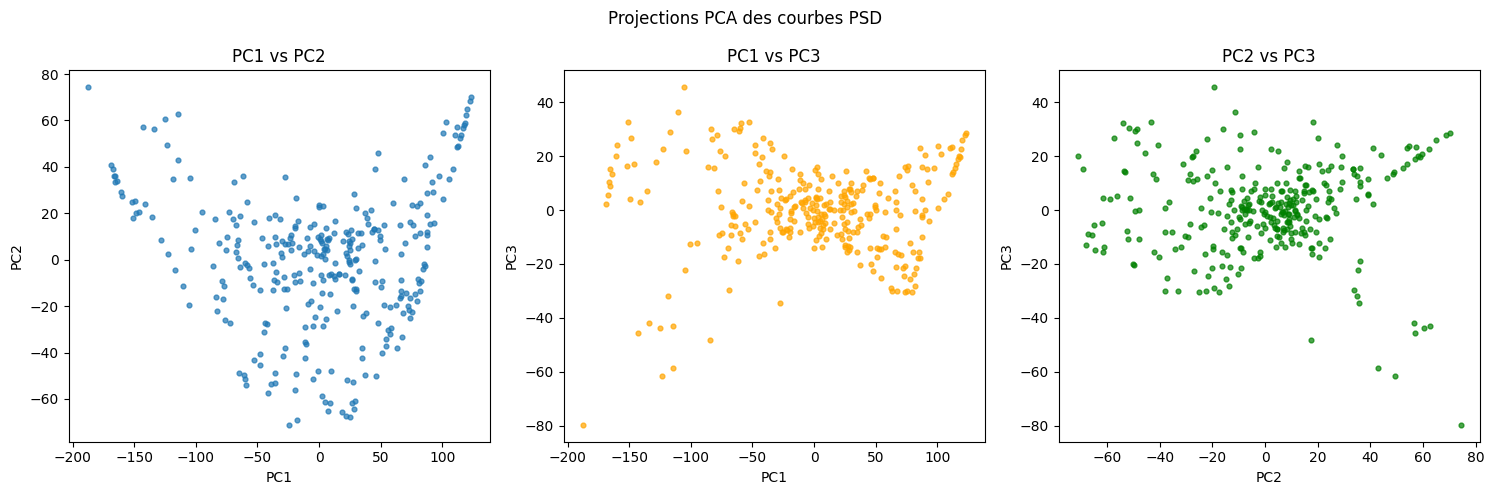

In [9]:
import matplotlib.pyplot as plt

# ---------------------------
# PCA
# ---------------------------
# Centrage par colonne
scaler = StandardScaler(with_mean=True, with_std=False)
X_centered = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_centered)

print("Variance expliquée par PC1, PC2, PC3:")
print(pca.explained_variance_ratio_)

# --- Affichage des 3 combinaisons de composantes principales ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PC1 vs PC2
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=12, alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2")

# PC1 vs PC3
axes[1].scatter(X_pca[:, 0], X_pca[:, 2], s=12, alpha=0.7, color='orange')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")
axes[1].set_title("PC1 vs PC3")

# PC2 vs PC3
axes[2].scatter(X_pca[:, 1], X_pca[:, 2], s=12, alpha=0.7, color='green')
axes[2].set_xlabel("PC2")
axes[2].set_ylabel("PC3")
axes[2].set_title("PC2 vs PC3")

plt.suptitle("Projections PCA des courbes PSD")
plt.tight_layout()
plt.show()

Variance expliquée par les 3 composantes :
PC1: 0.7658
PC2: 0.1431
PC3: 0.0453
Variance cumulative : 0.9541


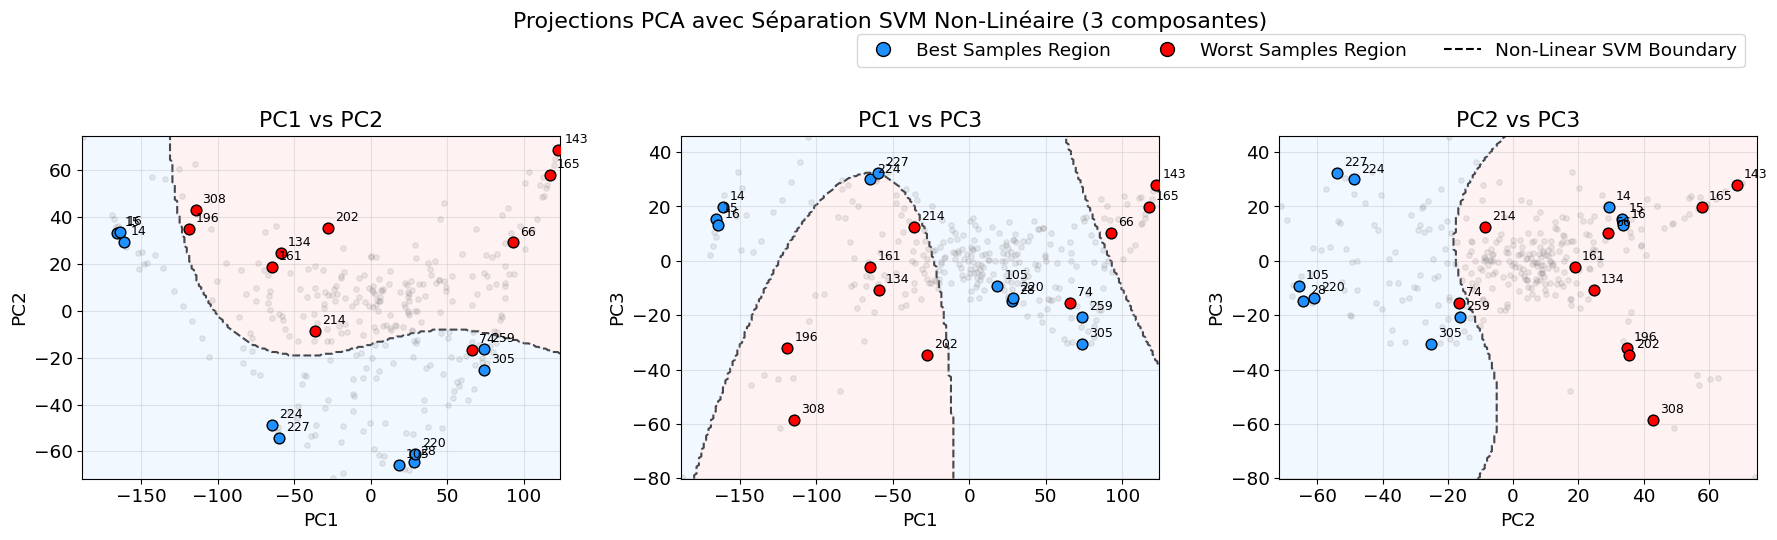

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

# ---------------------------
# Parameters
# ---------------------------
n_pca_components = 3  # Adjust this variable to change the number of components

# ---------------------------
# Targeted Samples (Best & Worst)
# ---------------------------
best_ids = [14, 15, 16, 28, 105, 220, 224, 227, 259, 305]
worst_ids = [66, 74, 134, 143, 161, 165, 196, 202, 214, 308]

safe_sample_ids = sample_ids.astype(str).str.extract(r'(\d+)')[0].dropna().astype(int)

best_indices = safe_sample_ids[safe_sample_ids.isin(best_ids)].index.tolist()
worst_indices = safe_sample_ids[safe_sample_ids.isin(worst_ids)].index.tolist()

# ---------------------------
# PCA
# ---------------------------
scaler = StandardScaler(with_mean=True, with_std=False)
X_centered = scaler.fit_transform(X)

pca = PCA(n_components=n_pca_components)
X_pca = pca.fit_transform(X_centered)

print(f"Variance expliquée par les {n_pca_components} composantes :")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")
print(f"Variance cumulative : {sum(pca.explained_variance_ratio_):.4f}")

# ---------------------------
# Dynamic Plotting Setup
# ---------------------------
# Generate all unique pairs of dimensions
pairs = list(itertools.combinations(range(n_pca_components), 2))
n_plots = len(pairs)

# Calculate grid dimensions (max 3 columns)
cols = min(3, n_plots)
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

if n_plots > 1:
    axes = axes.flatten()
else:
    axes = [axes]

def plot_pca_targeted(ax, x_col, y_col, xlabel, ylabel, title):
    
    # --- SVM Decision Boundary Logic (Non-Linear RBF Kernel) ---
    # Extract 2D coordinates for the target samples
    X_svm = np.vstack((X_pca[best_indices][:, [x_col, y_col]], 
                       X_pca[worst_indices][:, [x_col, y_col]]))
    # Create labels: 1 for Best, 0 for Worst
    y_svm = np.array([1] * len(best_indices) + [0] * len(worst_indices))

    # Train a non-linear Support Vector Machine using RBF
    clf = SVC(kernel='rbf', C=1.0, gamma='scale')
    clf.fit(X_svm, y_svm)

    # Generate a meshgrid covering the entire plot area
    x_min, x_max = X_pca[:, x_col].min() - 0.5, X_pca[:, x_col].max() + 0.5
    y_min, y_max = X_pca[:, y_col].min() - 0.5, X_pca[:, y_col].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict classifications for every point on the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision regions (Light Blue for Best, Light Red for Worst)
    cmap_bg = ListedColormap(['#ffe6e6', '#e6f2ff'])
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_bg, zorder=0)

    # Draw the explicit boundary line
    ax.contour(xx, yy, Z, colors='black', levels=[0.5], alpha=0.7, linestyles=['--'], linewidths=1.5, zorder=1)
    # -----------------------------------

    # 1. Background points
    ax.scatter(X_pca[:, x_col], X_pca[:, y_col], s=15, alpha=0.15, color='gray', zorder=2)
    
    # 2. Highlight Best Samples
    for idx in best_indices:
        x_val, y_val = X_pca[idx, x_col], X_pca[idx, y_col]
        act_id = sample_ids.iloc[idx]
        ax.scatter(x_val, y_val, s=60, color='dodgerblue', edgecolors='black', zorder=5)
        ax.annotate(str(act_id), (x_val, y_val), xytext=(5, 5), textcoords='offset points', fontsize=9, zorder=10)

    # 3. Highlight Worst Samples
    for idx in worst_indices:
        x_val, y_val = X_pca[idx, x_col], X_pca[idx, y_col]
        act_id = sample_ids.iloc[idx]
        ax.scatter(x_val, y_val, s=60, color='red', edgecolors='black', zorder=5)
        ax.annotate(str(act_id), (x_val, y_val), xytext=(5, 5), textcoords='offset points', fontsize=9, zorder=10)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# ---------------------------
# Render Dynamic Subplots
# ---------------------------
for i, (pc_a, pc_b) in enumerate(pairs):
    ax = axes[i]
    plot_pca_targeted(ax, pc_a, pc_b, f"PC{pc_a + 1}", f"PC{pc_b + 1}", f"PC{pc_a + 1} vs PC{pc_b + 1}")

# Remove empty subplots if grid is not perfectly filled
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Best Samples Region', markerfacecolor='dodgerblue', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Worst Samples Region', markerfacecolor='red', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Non-Linear SVM Boundary')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 1.05 if rows == 1 else 1.02), ncol=3)

plt.suptitle(f"Projections PCA avec Séparation SVM Non-Linéaire ({n_pca_components} composantes)", y=1.08 if rows == 1 else 1.03)
plt.tight_layout()
plt.show()